In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [39]:
df = pd.read_csv('Visadataset.csv')
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [40]:
from datetime import  datetime

todays_date = datetime.today()
current_year = todays_date.year
current_year

2026

In [41]:
df['company_age'] = current_year - df['yr_of_estab']

In [42]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [43]:
X = df.drop(columns=['case_status', 'case_id', 'yr_of_estab'])
y = df['case_status']
y

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: str

In [44]:
y = y.map({'Denied':1, 'Certified':0})
y

0        1
1        0
2        1
3        1
4        0
        ..
25475    0
25476    0
25477    0
25478    0
25479    0
Name: case_status, Length: 25480, dtype: int64

In [45]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
categorical_features = X.select_dtypes(include=['str']).columns.to_list()
discrete_features = [col for col in numeric_features if df[col].nunique() <=10]
continues_features = [col for col in numeric_features if col not in discrete_features]
continues_features

['no_of_employees', 'prevailing_wage', 'company_age']

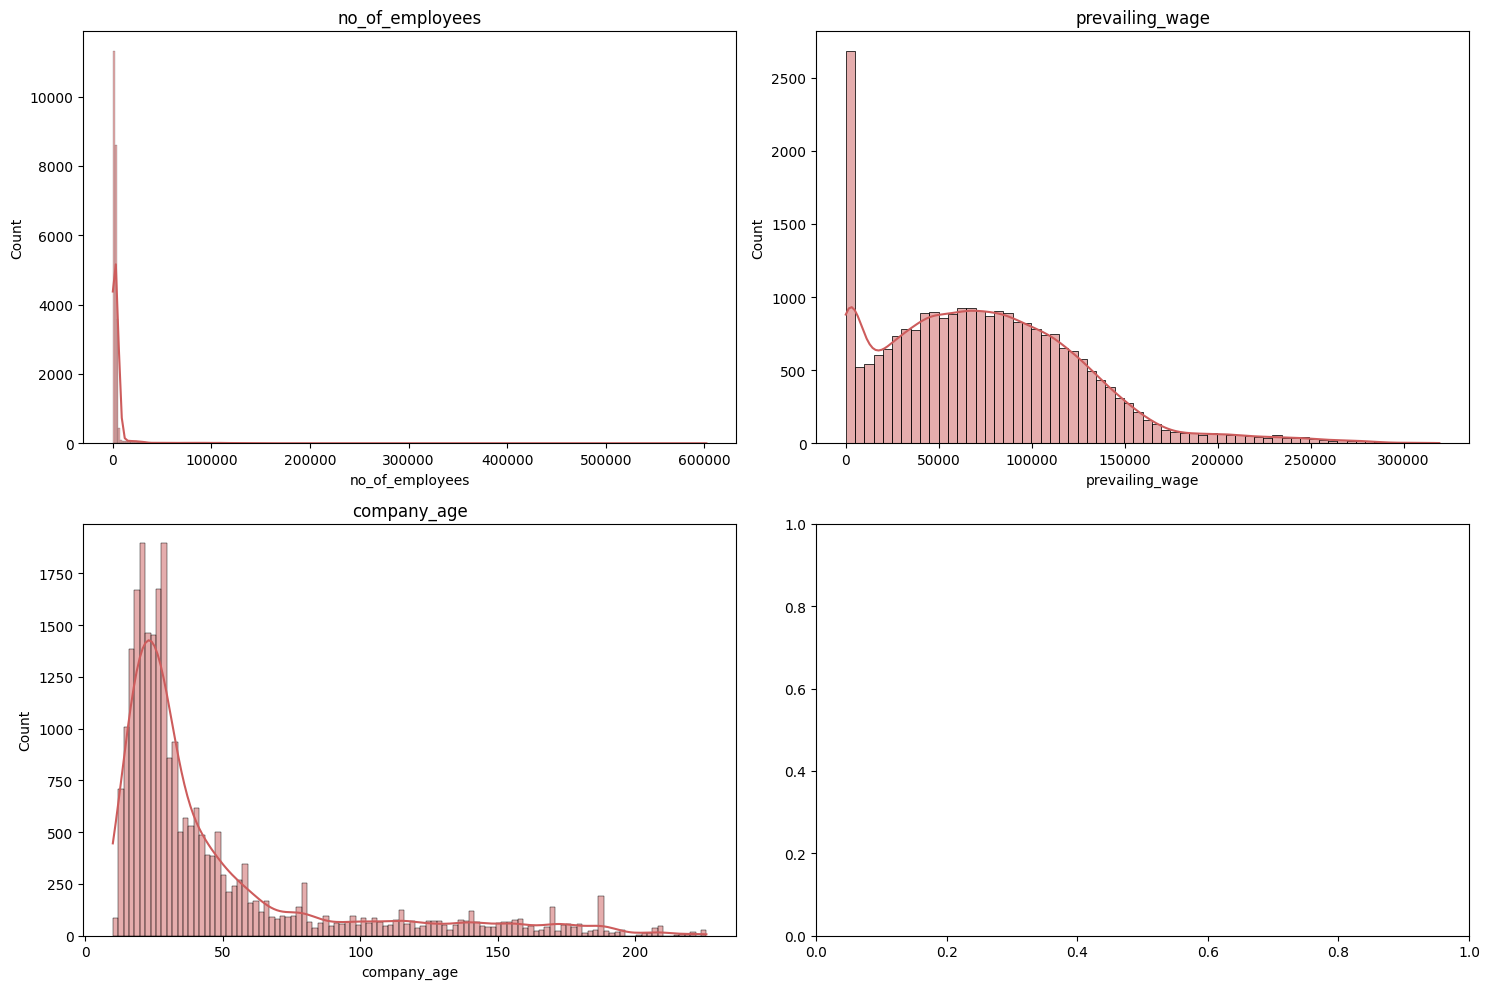

In [46]:

fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i],color = 'indianred')
    axes[i].set_title(feature)

plt.tight_layout() #This prevents plots from overlapping and adjusts spacing automatically.
plt.show()

In [47]:
X[continues_features].skew(axis=0, skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

In [48]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])


In [49]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)
X_copy

,company_age,no_of_employees
0,-0.958506,1.517300
1,-0.470816,0.030912
2,-1.080479,2.885076
3,1.632700,-1.343550
4,-0.741917,-0.432287
...,...,...
25475,-1.080479,0.079917
25476,-0.846032,0.235747
25477,1.552921,-0.413885
25478,1.685772,-0.111949


In [50]:
X_copy.skew(axis=0)

company_age        0.120823
no_of_employees    0.399339
dtype: float64

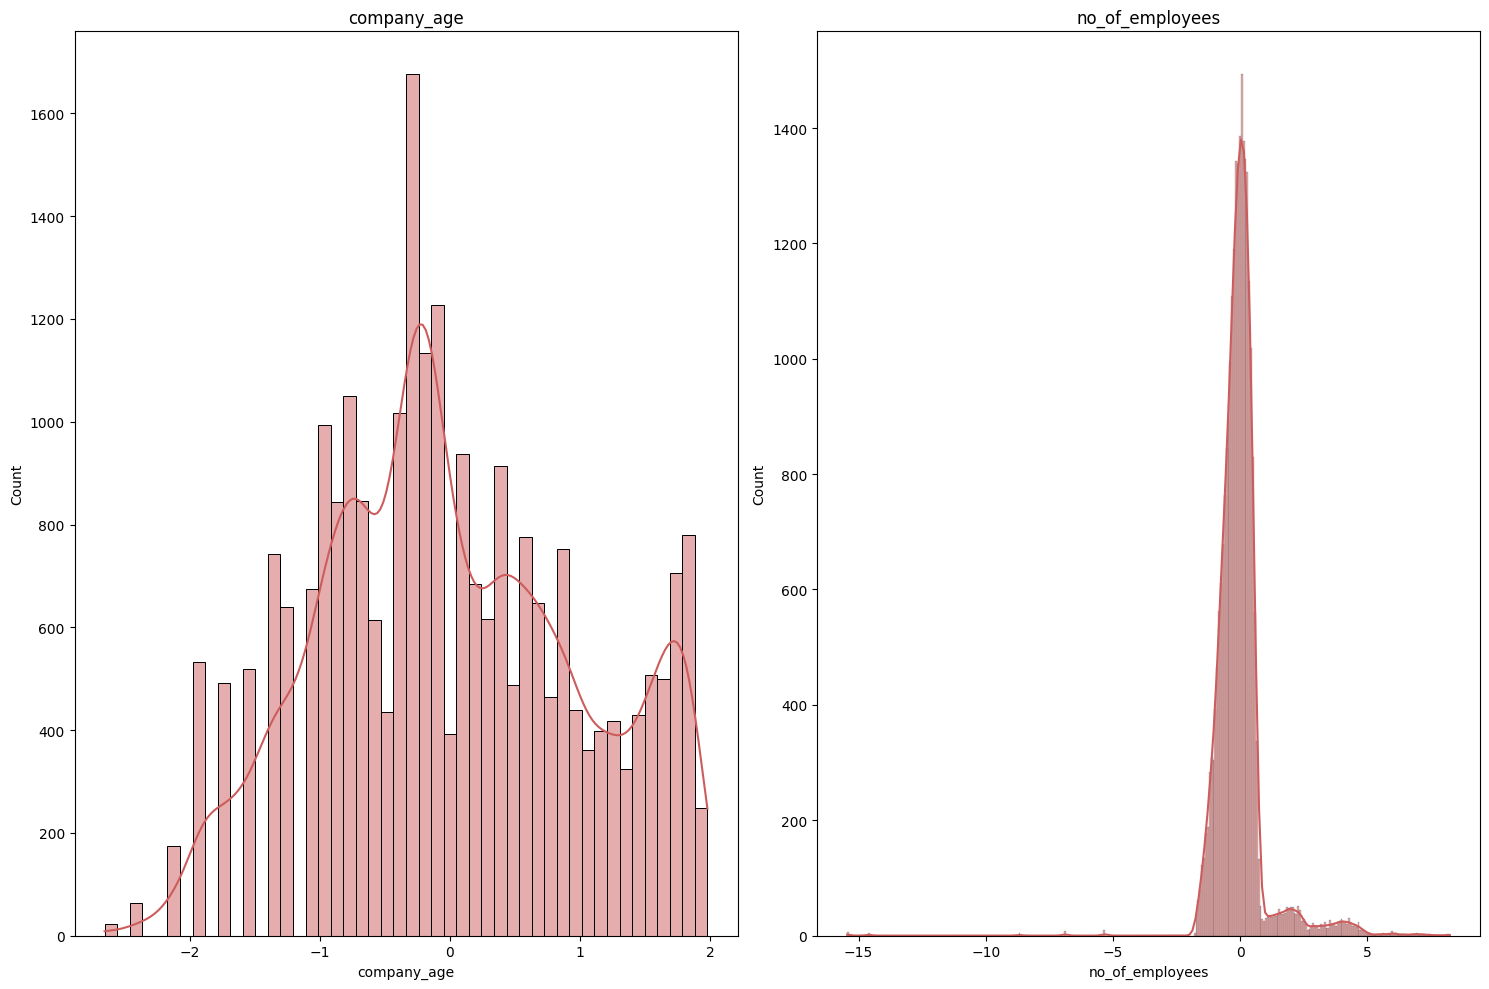

In [51]:

fig, axes = plt.subplots(1, 2, figsize=(15,10))
axes = axes.flatten()

for i, feature in enumerate(transform_features):
    sns.histplot(data=X_copy, x=feature, kde=True, ax=axes[i],color = 'indianred')
    axes[i].set_title(feature)

plt.tight_layout() #This prevents plots from overlapping and adjusts spacing automatically.
plt.show()

In [52]:
for feature in categorical_features:
    print(feature,':', df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2


In [53]:
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_columns = ['continent','unit_of_wage','region_of_employment']
transform_columns= ['no_of_employees','company_age']
num_features = ['prevailing_wage']

In [54]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

one_hot_encoding = OneHotEncoder()
standard_scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()
power_transformer = PowerTransformer(method="yeo-johnson")

"""Skewed Data
   ↓
Power Transform
   ↓
Scaling"""
power_pipeline = Pipeline(
    steps=[
        ("power_transform", power_transformer),
        ("scaler", standard_scaler)
    ]
)
ordinal_categories = [
    ['N','Y'],
    ['N','Y'],
    ['N','Y'],
    ['High School',"Bachelor's","Master's",'Doctorate']
]

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

preprocessor = ColumnTransformer(
    transformers = [
        ('OneHotEncoder', one_hot_encoding, oh_columns),
        ('StandardScaler', standard_scaler, num_features),
        ('OrdinalEncoder', ordinal_encoder, or_columns),
        ('Transformer', power_pipeline, transform_columns)
    ]
)

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTEENN(random_state=42,sampling_strategy="minority")),
    ("model", RandomForestClassifier())
])

In [57]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a strin

In [58]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [59]:
def evaluate_model(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [60]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN

import pandas as pd


def evaluate_models(X, y, models, preprocessor):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model_list = []
    accuracy_list = []

    for name, model in models.items():

        # Pipeline creation
        pipe = Pipeline([
            ("preprocessing", preprocessor),
            ("smote", SMOTEENN(random_state=42, sampling_strategy="minority")),
            ("model", model)
        ])

        # Train model
        pipe.fit(X_train, y_train)

        # Predictions
        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        # Training metrics
        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred)
        train_precision = precision_score(y_train, y_train_pred)
        train_recall = recall_score(y_train, y_train_pred)
        train_auc = roc_auc_score(y_train, y_train_pred)

        # Testing metrics
        test_acc = accuracy_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred)
        test_recall = recall_score(y_test, y_test_pred)
        test_auc = roc_auc_score(y_test, y_test_pred)

        print(name)

        print("Training Performance")
        print(f"Accuracy: {train_acc:.4f}")
        print(f"F1 Score: {train_f1:.4f}")
        print(f"Precision: {train_precision:.4f}")
        print(f"Recall: {train_recall:.4f}")
        print(f"ROC AUC: {train_auc:.4f}")

        print("----------------------------------")

        print("Test Performance")
        print(f"Accuracy: {test_acc:.4f}")
        print(f"F1 Score: {test_f1:.4f}")
        print(f"Precision: {test_precision:.4f}")
        print(f"Recall: {test_recall:.4f}")
        print(f"ROC AUC: {test_auc:.4f}")

        print("="*35)

        model_list.append(name)
        accuracy_list.append(test_acc)

    report = pd.DataFrame(
        list(zip(model_list, accuracy_list)),
        columns=["Model Name", "Accuracy"]
    ).sort_values(by="Accuracy", ascending=False)

    return report

In [62]:
base_model_report =evaluate_models(X, y, models, preprocessor)
base_model_report

Random Forest
Training Performance
Accuracy: 0.7596
F1 Score: 0.6809
Precision: 0.6086
Recall: 0.7727
ROC AUC: 0.7629
----------------------------------
Test Performance
Accuracy: 0.7121
F1 Score: 0.6197
Precision: 0.5527
Recall: 0.7050
ROC AUC: 0.7103
Decision Tree
Training Performance
Accuracy: 0.7558
F1 Score: 0.6781
Precision: 0.6029
Recall: 0.7748
ROC AUC: 0.7606
----------------------------------
Test Performance
Accuracy: 0.6909
F1 Score: 0.5946
Precision: 0.5274
Recall: 0.6814
ROC AUC: 0.6885
Gradient Boosting
Training Performance
Accuracy: 0.6946
F1 Score: 0.6181
Precision: 0.5284
Recall: 0.7445
ROC AUC: 0.7072
----------------------------------
Test Performance
Accuracy: 0.7019
F1 Score: 0.6282
Precision: 0.5368
Recall: 0.7569
ROC AUC: 0.7157
Logistic Regression
Training Performance
Accuracy: 0.6649
F1 Score: 0.6031
Precision: 0.4969
Recall: 0.7670
ROC AUC: 0.6906
----------------------------------
Test Performance
Accuracy: 0.6684
F1 Score: 0.6104
Precision: 0.5009
Recall: 0

,Model Name,Accuracy
6,CatBoosting Classifier,0.722135
0,Random Forest,0.712127
5,XGBClassifier,0.706240
7,Support Vector Classifier,0.705259
2,Gradient Boosting,0.701923
1,Decision Tree,0.690934
8,AdaBoost Classifier,0.682496
4,K-Neighbors Classifier,0.675432
3,Logistic Regression,0.668367


In [63]:
base_model_report

,Model Name,Accuracy
6,CatBoosting Classifier,0.722135
0,Random Forest,0.712127
5,XGBClassifier,0.706240
7,Support Vector Classifier,0.705259
2,Gradient Boosting,0.701923
1,Decision Tree,0.690934
8,AdaBoost Classifier,0.682496
4,K-Neighbors Classifier,0.675432
3,Logistic Regression,0.668367


In [64]:
xgboost_params = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree','brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9],
}

In [65]:
randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline # Make sure to use imblearn's pipeline if using SMOTE
from imblearn.combine import SMOTEENN

# 1. Define your models and their parameter grids
randomcv_models = [
    (
        "Random Forest", 
        RandomForestClassifier(random_state=42),
        {
            # Notice the "model__" prefix! This tells the Pipeline that these params belong to the model step
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [10, 20, 30, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    ),
    (
        "XGBClassifier", 
        XGBClassifier(random_state=42),
        {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__max_depth": [3, 5, 7, 10],
            "model__gamma": [0, 0.1, 0.2]
        }
    )
]

model_param = {}

for name, model, params in randomcv_models:
    
    # 2. Build the pipeline containing the preprocessor, SMOTE, and the model
    # (If you decided to remove SMOTE to test class_weights, just remove that step here)
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTEENN(random_state=42, sampling_strategy="minority")),
        ("model", model)
    ])

    # 3. Pass the PIPELINE into RandomizedSearchCV, not just the model
    random = RandomizedSearchCV(
        estimator=pipe, 
        param_distributions=params,
        n_iter=20, # Reduced n_iter slightly to save time, adjust as needed
        cv=3,
        verbose=2, 
        n_jobs=-1,
        scoring='accuracy' # Specify the metric to optimize
    )
    
    # Now you can safely pass the raw X and y because the pipeline handles the transformations!
    print(f"--- Running RandomizedSearchCV for {name} ---")
    random.fit(X_train, y_train) # It's better practice to use X_train over X here to keep a pristine test set
    
    model_param[name] = random.best_params_
    print(f"Best parameters for {name}: {random.best_params_}\n")



--- Running RandomizedSearchCV for Random Forest ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for Random Forest: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 10}

--- Running RandomizedSearchCV for XGBClassifier ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for XGBClassifier: {'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.1}



In [70]:
model_param

{'Random Forest': {'model__n_estimators': 300,
  'model__min_samples_split': 5,
  'model__min_samples_leaf': 4,
  'model__max_depth': 10},
 'XGBClassifier': {'model__n_estimators': 200,
  'model__max_depth': 3,
  'model__learning_rate': 0.05,
  'model__gamma': 0.1}}

In [71]:
from sklearn.metrics import roc_auc_score, roc_curve

# Helper logic to strip the "model__" prefix from the tuned parameters
rf_params = {k.replace('model__', ''): v for k, v in model_param['Random Forest'].items()}
xgb_params = {k.replace('model__', ''): v for k, v in model_param['XGBClassifier'].items()}

# Now pass those cleaned dictionaries into the models
best_models = {
    "Random Forest Classifier": RandomForestClassifier(**rf_params, random_state=42),
    "XGBClassifier": XGBClassifier(**xgb_params, n_jobs=-1, random_state=42),
}

# Evaluate the models using your pre-built function
tuned_report = evaluate_models(X=X, y=y, models=best_models, preprocessor=preprocessor)
print(tuned_report)


Random Forest Classifier
Training Performance
Accuracy: 0.7083
F1 Score: 0.6313
Precision: 0.5439
Recall: 0.7522
ROC AUC: 0.7194
----------------------------------
Test Performance
Accuracy: 0.7031
F1 Score: 0.6272
Precision: 0.5385
Recall: 0.7510
ROC AUC: 0.7151
XGBClassifier
Training Performance
Accuracy: 0.6908
F1 Score: 0.6180
Precision: 0.5238
Recall: 0.7535
ROC AUC: 0.7066
----------------------------------
Test Performance
Accuracy: 0.6962
F1 Score: 0.6250
Precision: 0.5302
Recall: 0.7611
ROC AUC: 0.7125
                 Model Name  Accuracy
0  Random Forest Classifier  0.703100
1             XGBClassifier  0.696232
